# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [2]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

In business terms, the objective is to build a reliable property-valuation model that estimates `taxvaluedollarcnt` from available parcel and home characteristics, so Zillow can improve pricing intelligence, reduce manual valuation effort, and support better decisions in marketing, acquisition, and homeowner-facing valuation products.

**1.2:**  How will your solution be used?

The solution would be used as a decision-support tool: marketing and product teams can use predicted values to segment properties, prioritize outreach, and personalize messaging; analysts can compare predicted vs. assessed values to spot unusual cases; and downstream systems can use predictions as one input for pricing and portfolio analysis (with human review for high-impact decisions).

**1.3:**  How should success (or failure) be measured?

Success should be measured primarily with regression error metrics such as RMSE and MAE on held-out data, tracked alongside robustness checks across property subgroups (for example, by location or land-use type). From a business perspective, success also means predictions are stable enough to improve targeting and valuation workflows relative to a baseline approach, while failure would show up as large, systematic errors or unstable performance across segments.

## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [5]:
# Part 2.A — feature-level audit (with Appendix 1 context in mind)

# Quick peek at the raw data
print("Shape:", df.shape)
display(df.head())

# Basic schema inspection
info_buffer = io.StringIO()
df.info(buf=info_buffer)
print(info_buffer.getvalue())

# Build a compact audit table for every feature
missing_pct = (df.isnull().mean() * 100).round(2)
unique_counts = df.nunique(dropna=True)

# Heuristic categorization
id_like_cols = [
    col for col in df.columns
    if col.endswith("id") or col in ["parcelid", "fips", "rawcensustractandblock", "censustractandblock"]
]
object_cols = df.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()

categorical_candidates = sorted(set(object_cols + id_like_cols) - {"taxvaluedollarcnt"})

feature_audit = pd.DataFrame({
    "feature": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_pct": [missing_pct[c] for c in df.columns],
    "unique_values": [unique_counts[c] for c in df.columns],
})

feature_audit["type_guess"] = np.where(
    feature_audit["feature"].isin(categorical_candidates),
    "categorical / code",
    "numeric"
)

feature_audit["apparent_usefulness"] = "likely useful"
feature_audit.loc[
    feature_audit["feature"].isin(["parcelid", "rawcensustractandblock", "censustractandblock"]),
    "apparent_usefulness"
] = "likely low (identifier)"
feature_audit.loc[
    feature_audit["unique_values"] > 0.95 * len(df),
    "apparent_usefulness"
] = "potentially low (near-unique)"
feature_audit.loc[
    feature_audit["missing_pct"] > 95,
    "apparent_usefulness"
] = "potentially low (extreme missingness)"
feature_audit.loc[
    feature_audit["feature"] == "taxvaluedollarcnt",
    "apparent_usefulness"
] = "target"

# Display full audit sorted by missingness (descending)
display(feature_audit.sort_values("missing_pct", ascending=False).reset_index(drop=True))

print("\nCategorical feature candidates:")
print(categorical_candidates)

print("\nTop 15 features by missing %:")
print(feature_audit.sort_values("missing_pct", ascending=False)[["feature", "missing_pct"]].head(15).to_string(index=False))

near_unique_cols = feature_audit.loc[
    feature_audit["unique_values"] > 0.95 * len(df), "feature"
].tolist()
print("\nNear-unique features (>95% unique values):")
print(near_unique_cols)

print("\nTarget missing %:", float(missing_pct["taxvaluedollarcnt"]))

Shape: (77613, 55)


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0


<class 'pandas.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12          73923 non-null  float64
 13  finishedsqua

,feature,dtype,missing_pct,unique_values,type_guess,apparent_usefulness
0,buildingclasstypeid,float64,99.98,2,categorical / code,potentially low (extreme missingness)
1,finishedsquarefeet13,float64,99.95,13,numeric,potentially low (extreme missingness)
2,basementsqft,float64,99.94,43,numeric,potentially low (extreme missingness)
3,storytypeid,float64,99.94,1,categorical / code,potentially low (extreme missingness)
4,yardbuildingsqft26,float64,99.91,59,numeric,potentially low (extreme missingness)
5,fireplaceflag,object,99.78,1,categorical / code,potentially low (extreme missingness)
6,architecturalstyletypeid,float64,99.73,5,categorical / code,potentially low (extreme missingness)
7,typeconstructiontypeid,float64,99.71,4,categorical / code,potentially low (extreme missingness)
8,finishedsquarefeet6,float64,99.50,350,numeric,potentially low (extreme missingness)
9,pooltypeid10,float64,99.40,1,numeric,potentially low (extreme missingness)



Categorical feature candidates:
['airconditioningtypeid', 'architecturalstyletypeid', 'buildingclasstypeid', 'buildingqualitytypeid', 'censustractandblock', 'decktypeid', 'fips', 'fireplaceflag', 'hashottuborspa', 'heatingorsystemtypeid', 'parcelid', 'propertycountylandusecode', 'propertylandusetypeid', 'propertyzoningdesc', 'rawcensustractandblock', 'storytypeid', 'taxdelinquencyflag', 'typeconstructiontypeid']

Top 15 features by missing %:
                 feature  missing_pct
     buildingclasstypeid        99.98
    finishedsquarefeet13        99.95
            basementsqft        99.94
             storytypeid        99.94
      yardbuildingsqft26        99.91
           fireplaceflag        99.78
architecturalstyletypeid        99.73
  typeconstructiontypeid        99.71
     finishedsquarefeet6        99.50
            pooltypeid10        99.40
              decktypeid        99.21
             poolsizesum        98.88
             pooltypeid2        98.62
          hashottubo

#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Based on data type and Appendix 1 semantics, the clearest categorical features are `propertycountylandusecode`, `propertyzoningdesc`, `taxdelinquencyflag`, `hashottuborspa`, and `fireplaceflag` (string/flag-style fields), plus many integer/float-coded category IDs such as `airconditioningtypeid`, `heatingorsystemtypeid`, `propertylandusetypeid`, `buildingqualitytypeid`, `architecturalstyletypeid`, and related `*id` columns.

**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly. 

Yes—some fields look like record identifiers rather than predictive property attributes. For example, `parcelid` (near-unique ID), `rawcensustractandblock`, and `censustractandblock` are mostly location/administrative codes that can act like high-cardinality lookup keys and may not generalize well as-is. These are good candidates to drop (or to replace with better engineered location features later).

**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example. 

Yes. Several columns have extreme missingness (around 99%+), which makes them difficult to use reliably at this stage. Examples include `buildingclasstypeid` (99.98% missing), `finishedsquarefeet13` (99.95%), `basementsqft` (99.94%), and `storytypeid` (99.94%). With so few observed values, these features are likely poor candidates unless a later model can exploit sparse signals very effectively.

**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example. 

Yes. `parcelid` is effectively near-unique per row (>95% unique), so it behaves like an identifier rather than a reusable predictor. Features like this often encourage overfitting and usually add little business insight for valuation, so they are typically removed from the modeling feature set.

### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

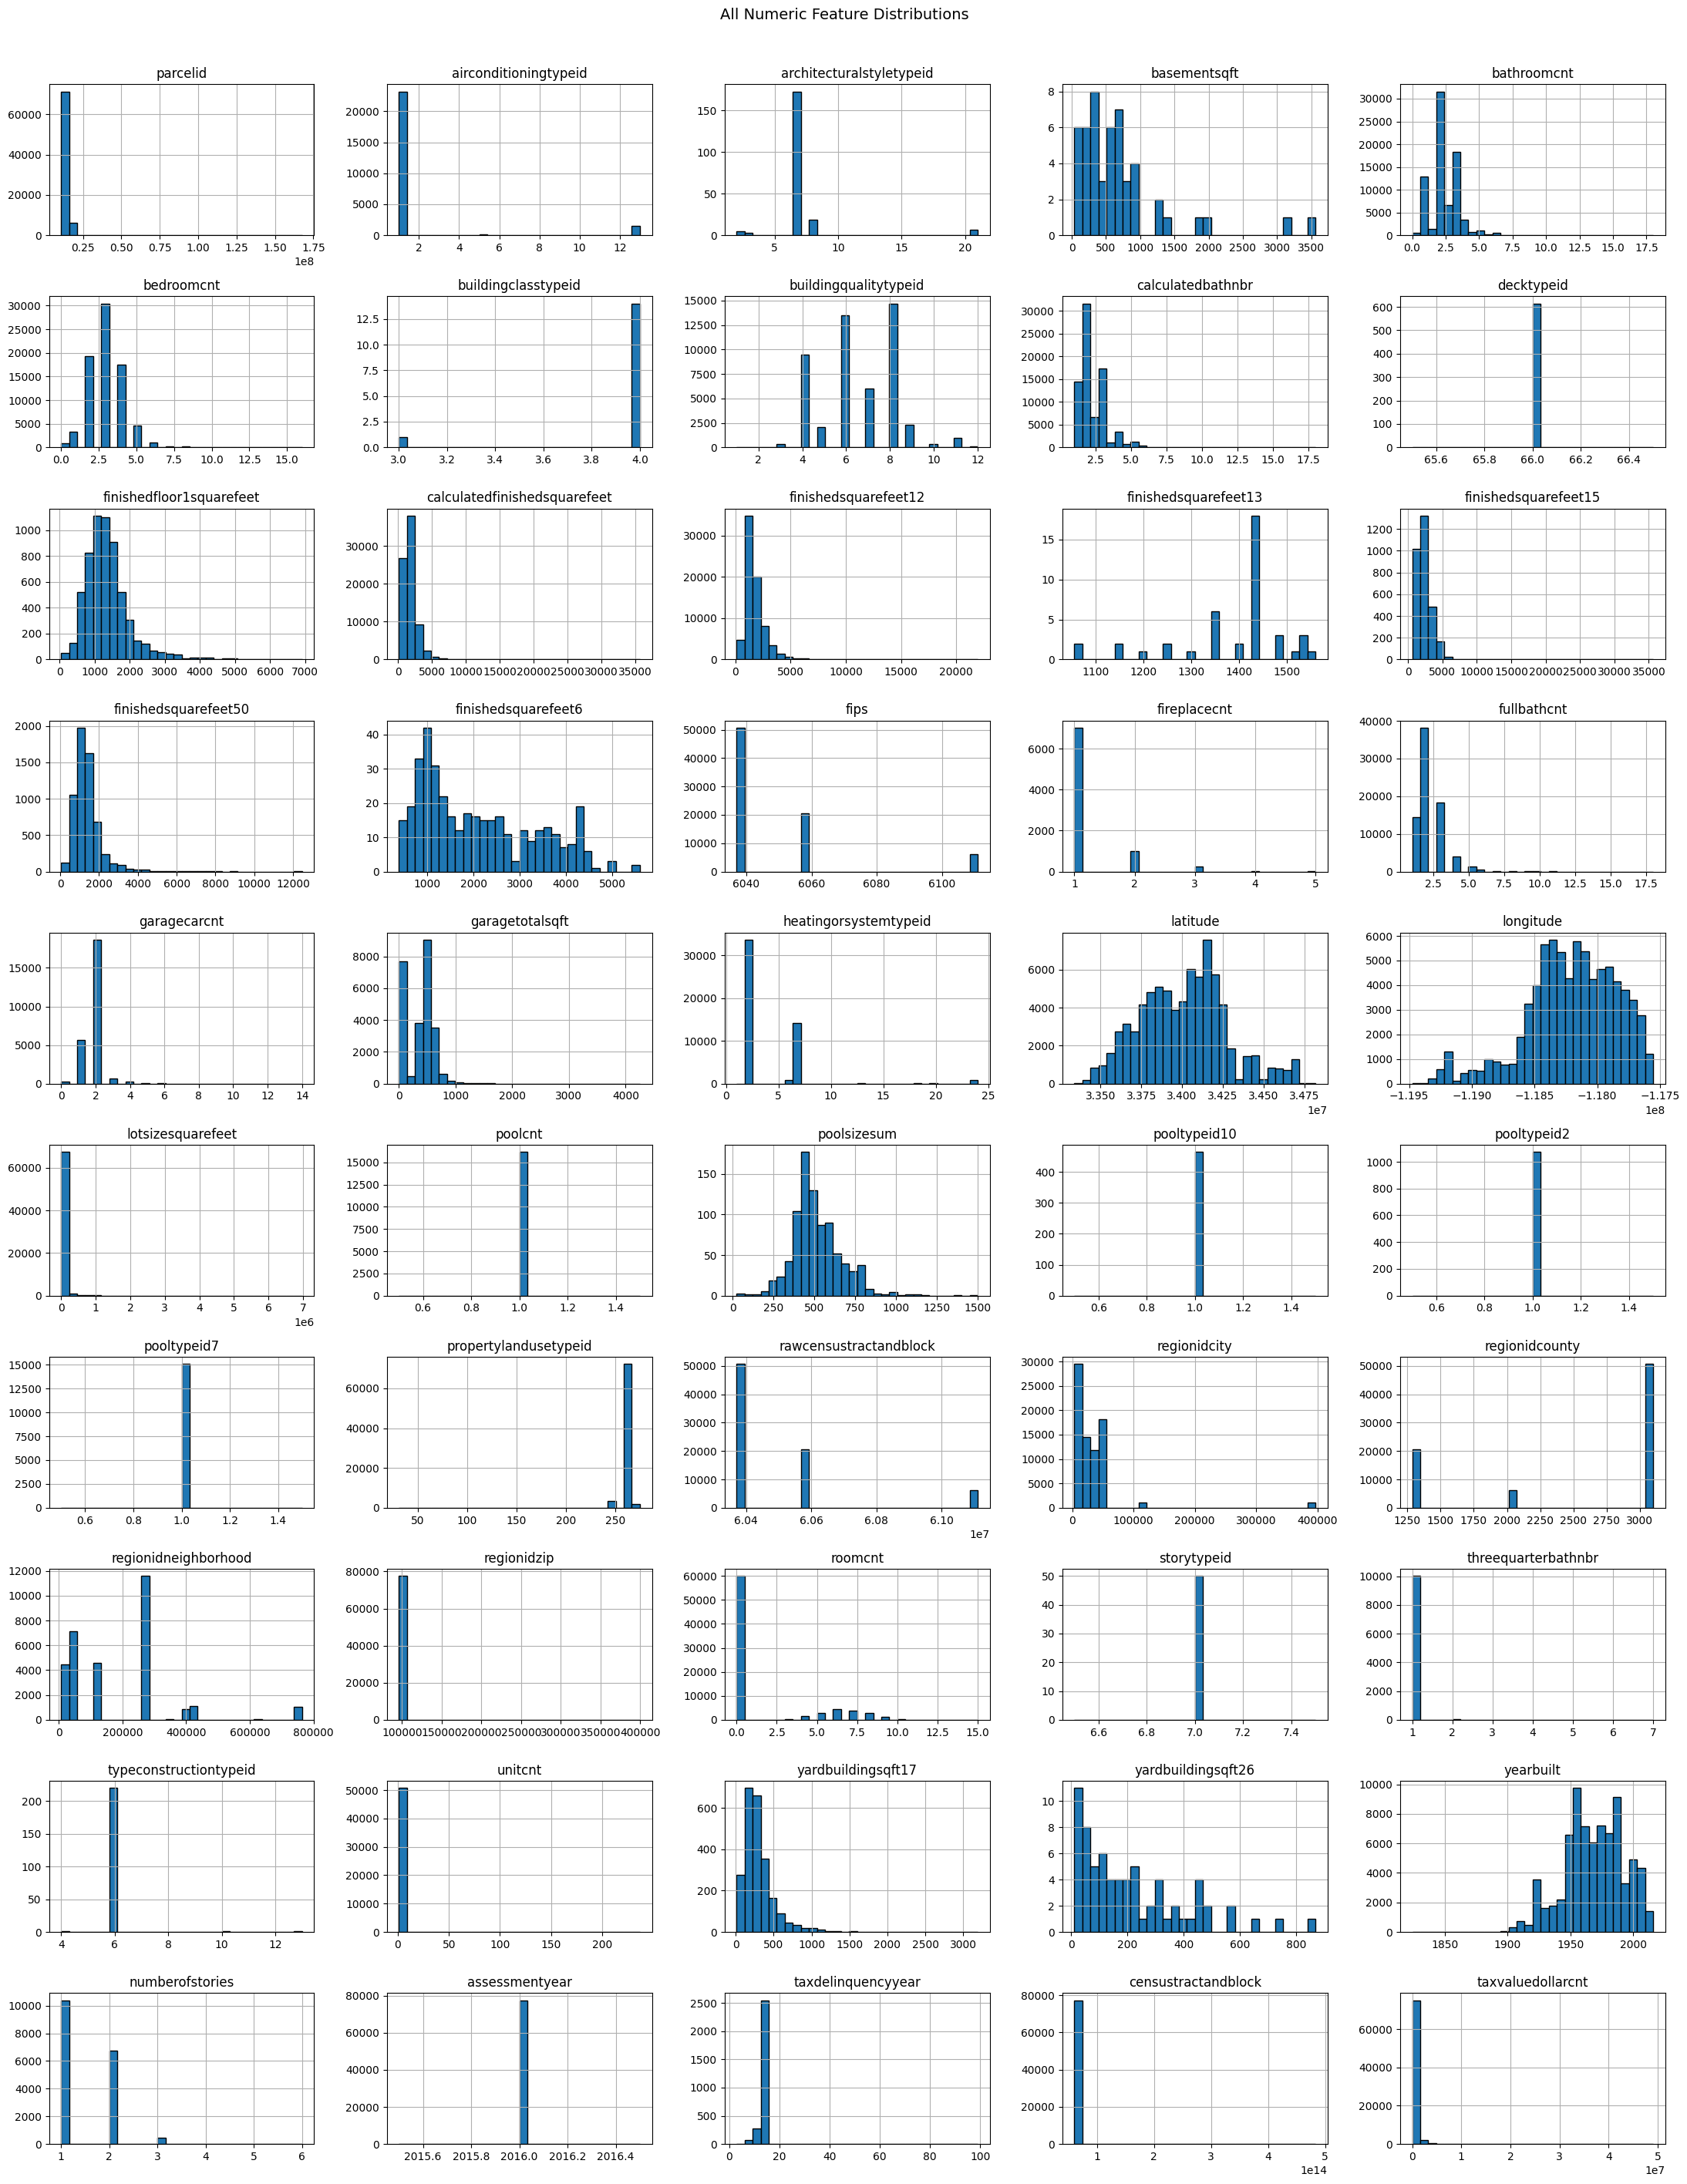

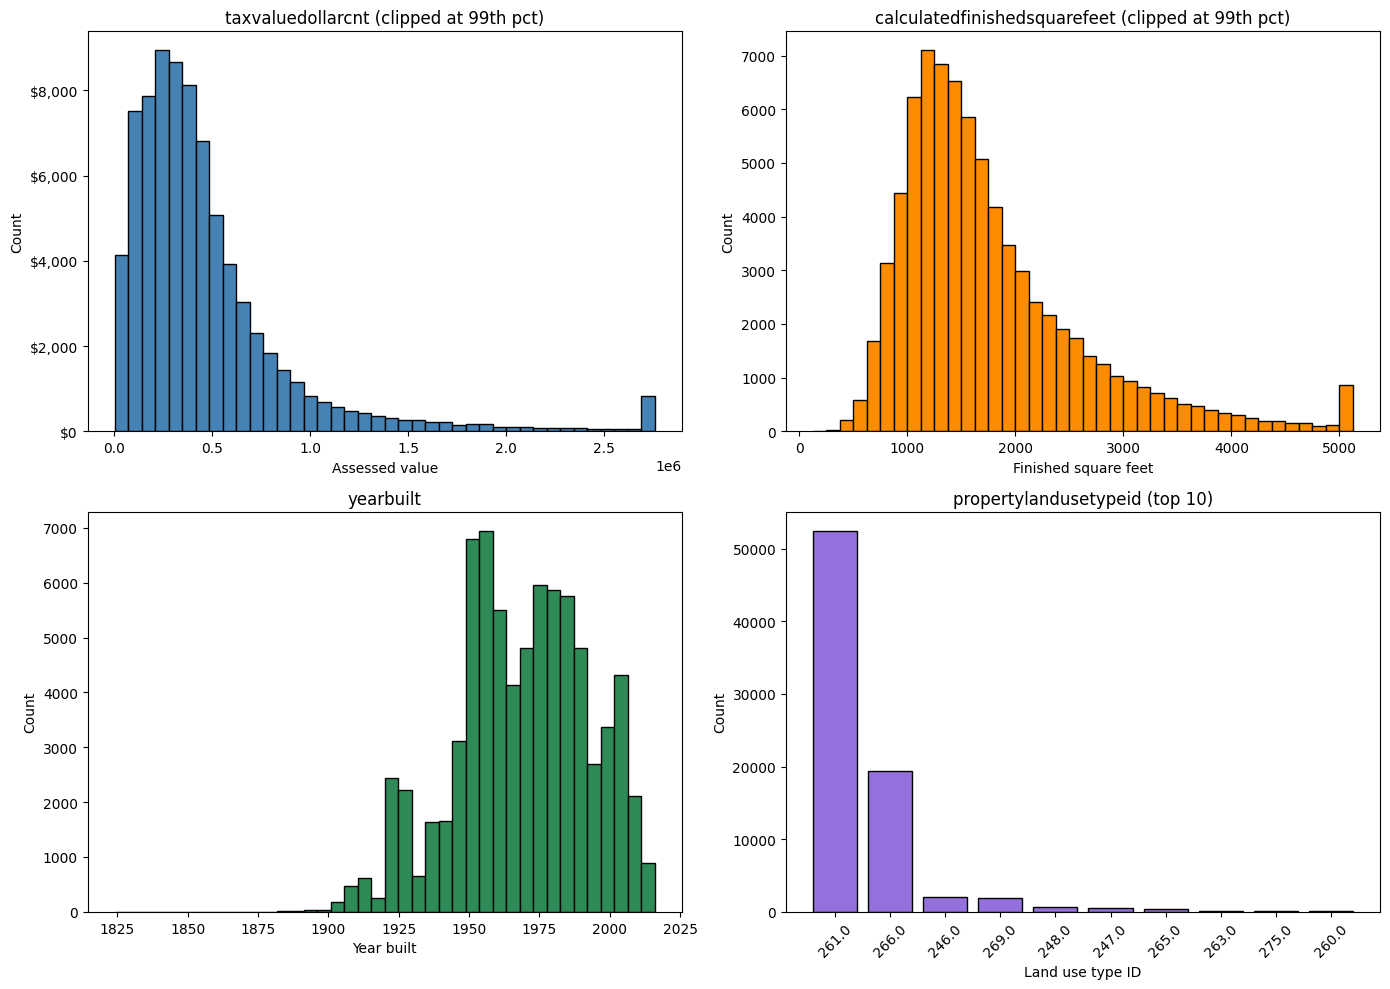

Target quantiles:
0.50     358878.50
0.90     904278.20
0.95    1290000.00
0.99    2758771.31

calculatedfinishedsquarefeet quantiles:
0.50    1542.00
0.90    2924.00
0.95    3540.00
0.99    5125.38

Missingness of selected features (%):
taxvaluedollarcnt               0.05
calculatedfinishedsquarefeet    0.30
yearbuilt                       0.39
propertylandusetypeid           0.04


In [4]:
# Part 2.B — EDA visualizations

# 1) Broad overview: histograms for all numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns
_ = df[numeric_cols].hist(figsize=(22, 28), bins=30, layout=(-1, 5), edgecolor="black")
plt.suptitle("All Numeric Feature Distributions", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

# 2) Detailed examination: target + three interesting features
selected_features = [
    "taxvaluedollarcnt",            # target
    "calculatedfinishedsquarefeet", # size-related
    "yearbuilt",                    # age-related
    "propertylandusetypeid"         # categorical/code feature
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Target (histogram, clipped at 99th percentile for readability)
target_clip = df["taxvaluedollarcnt"].clip(upper=df["taxvaluedollarcnt"].quantile(0.99))
axes[0].hist(target_clip.dropna(), bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("taxvaluedollarcnt (clipped at 99th pct)")
axes[0].set_xlabel("Assessed value")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

# Numerical feature: calculatedfinishedsquarefeet
sqft_clip = df["calculatedfinishedsquarefeet"].clip(upper=df["calculatedfinishedsquarefeet"].quantile(0.99))
axes[1].hist(sqft_clip.dropna(), bins=40, color="darkorange", edgecolor="black")
axes[1].set_title("calculatedfinishedsquarefeet (clipped at 99th pct)")
axes[1].set_xlabel("Finished square feet")
axes[1].set_ylabel("Count")

# Numerical feature: yearbuilt
axes[2].hist(df["yearbuilt"].dropna(), bins=40, color="seagreen", edgecolor="black")
axes[2].set_title("yearbuilt")
axes[2].set_xlabel("Year built")
axes[2].set_ylabel("Count")

# Categorical/code feature: propertylandusetypeid (top classes)
landuse_counts = df["propertylandusetypeid"].value_counts().head(10)
axes[3].bar(landuse_counts.index.astype(str), landuse_counts.values, color="mediumpurple", edgecolor="black")
axes[3].set_title("propertylandusetypeid (top 10)")
axes[3].set_xlabel("Land use type ID")
axes[3].set_ylabel("Count")
axes[3].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# Quick outlier/missingness checkpoints for discussion
print("Target quantiles:")
print(df["taxvaluedollarcnt"].quantile([0.5, 0.9, 0.95, 0.99]).to_string())

print("\ncalculatedfinishedsquarefeet quantiles:")
print(df["calculatedfinishedsquarefeet"].quantile([0.5, 0.9, 0.95, 0.99]).to_string())

print("\nMissingness of selected features (%):")
print((df[selected_features].isnull().mean() * 100).round(2).to_string())

#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?

The target `taxvaluedollarcnt` is strongly right-skewed, with a long high-value tail (median ≈ $358,879 and 99th percentile ≈ $2.76M), so outliers are clearly present and may affect regression loss. `calculatedfinishedsquarefeet` is also right-skewed (median 1,542 sqft; 99th percentile ≈ 5,125 sqft), which is plausible for housing size but suggests extreme properties exist. `yearbuilt` is not normal; it is multi-peaked with most homes concentrated in mid/late 20th century decades, indicating historical development waves. `propertylandusetypeid` is highly imbalanced, dominated by one or two categories (especially 261 and 266), so category imbalance should be considered in later modeling/encoding decisions. I chose these features because they represent target behavior, physical size, age, and land-use class—four core valuation dimensions.

## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [4]:
# Part 3.A: drop features unsuitable for regression task (not based on missingness)

manual_drop_cols = [
    "parcelid",
    "rawcensustractandblock",
    "censustractandblock",
    "assessmentyear"
]

X3a = df.copy()
existing_manual_drop_cols = [c for c in manual_drop_cols if c in X3a.columns]
X3a = X3a.drop(columns=existing_manual_drop_cols)

print("Part 3.A")
print("Original shape:", df.shape)
print("Dropped columns:", existing_manual_drop_cols)
print("Shape after 3.A:", X3a.shape)

Part 3.A
Original shape: (77613, 55)
Dropped columns: ['parcelid', 'rawcensustractandblock', 'censustractandblock', 'assessmentyear']
Shape after 3.A: (77613, 51)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop. 

I dropped `parcelid`, `rawcensustractandblock`, and `censustractandblock` because they function mostly as identifiers/codes rather than direct, generalizable property descriptors; they can add noise or overfitting risk without giving interpretable valuation signal in this form. I also dropped `assessmentyear` because it appears to be effectively constant in this dataset and therefore contributes little predictive value. This reduced the data from 55 to 51 columns while preserving the core structural, geographic, and property-condition attributes for later cleaning steps.

### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [5]:
# Part 3.B: drop features with too many null values

null_threshold_pct = 95.0
missing_pct_3a = X3a.isnull().mean() * 100
high_null_cols = missing_pct_3a[missing_pct_3a > null_threshold_pct].sort_values(ascending=False).index.tolist()

X3b = X3a.drop(columns=high_null_cols)

print("Part 3.B")
print(f"Threshold for dropping columns: > {null_threshold_pct:.0f}% missing")
print("Columns dropped due to high missingness:", len(high_null_cols))
print(high_null_cols)
print("Shape after 3.B:", X3b.shape)

print("\nHighest remaining missing percentages:")
print((X3b.isnull().mean() * 100).sort_values(ascending=False).head(10).round(2).to_string())

Part 3.B
Threshold for dropping columns: > 95% missing
Columns dropped due to high missingness: 18
['buildingclasstypeid', 'finishedsquarefeet13', 'storytypeid', 'basementsqft', 'yardbuildingsqft26', 'fireplaceflag', 'architecturalstyletypeid', 'typeconstructiontypeid', 'finishedsquarefeet6', 'pooltypeid10', 'decktypeid', 'poolsizesum', 'pooltypeid2', 'hashottuborspa', 'yardbuildingsqft17', 'taxdelinquencyflag', 'taxdelinquencyyear', 'finishedsquarefeet15']
Shape after 3.B: (77613, 33)

Highest remaining missing percentages:
finishedsquarefeet50        92.22
finishedfloor1squarefeet    92.22
fireplacecnt                89.32
threequarterbathnbr         86.98
pooltypeid7                 80.57
poolcnt                     79.16
numberofstories             77.32
airconditioningtypeid       67.78
garagecarcnt                67.12
garagetotalsqft             67.12


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

I used a >95% missingness threshold to define “too many” nulls and dropped 18 features that exceeded it (for example `buildingclasstypeid`, `finishedsquarefeet13`, `storytypeid`, `basementsqft`, and several sparse pool/yard flags). With this rule, columns that are almost entirely empty were removed because they provide too little observed signal for stable modeling at this stage. After dropping them, the dataset moved from 51 to 33 columns; importantly, some columns with high but not extreme missingness (such as `finishedsquarefeet50` and `fireplacecnt`) were intentionally retained so they can be handled by imputation rather than discarded prematurely.

### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [6]:
# Part 3.C: drop problematic samples

X3c = X3b.copy()
rows_before_3c = len(X3c)

# 1) Drop rows with null target
null_target_mask = X3c["taxvaluedollarcnt"].isnull()
rows_null_target = int(null_target_mask.sum())
X3c = X3c.loc[~null_target_mask].copy()

# 2) Drop rows with too many nulls across remaining features
row_null_fraction = X3c.isnull().mean(axis=1)
row_null_threshold = 0.40
rows_too_many_nulls = int((row_null_fraction > row_null_threshold).sum())
X3c = X3c.loc[row_null_fraction <= row_null_threshold].copy()

# 3) Drop extreme outliers in target (above 99.5 percentile)
outlier_cutoff = X3c["taxvaluedollarcnt"].quantile(0.995)
outlier_mask = X3c["taxvaluedollarcnt"] > outlier_cutoff
rows_outliers = int(outlier_mask.sum())
X3c = X3c.loc[~outlier_mask].copy()

rows_after_3c = len(X3c)

print("Part 3.C")
print("Rows before 3.C:", rows_before_3c)
print("Rows removed (null target):", rows_null_target)
print(f"Rows removed (> {row_null_threshold:.0%} null fields):", rows_too_many_nulls)
print("Outlier cutoff (99.5th pct of target):", round(float(outlier_cutoff), 2))
print("Rows removed (target outliers):", rows_outliers)
print("Rows after 3.C:", rows_after_3c)
print("Total rows removed in 3.C:", rows_before_3c - rows_after_3c)

Part 3.C
Rows before 3.C: 77613
Rows removed (null target): 35
Rows removed (> 40% null fields): 3166
Outlier cutoff (99.5th pct of target): 3706387.76
Rows removed (target outliers): 373
Rows after 3.C: 74039
Total rows removed in 3.C: 3574


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

I removed samples in three passes: rows with null target (`taxvaluedollarcnt`) values (35 rows), rows with more than 40% missing fields after feature filtering (3,166 rows), and extreme target outliers above the 99.5th percentile cutoff ($3,706,387.76; 373 rows). This produced a cleaner set of 74,039 rows from 77,613 total (3,574 removed). The goal was to keep most observations while removing cases that are either unusable for supervised regression (missing target), too incomplete, or likely to disproportionately distort error-based model training.

### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [7]:
# Part 3.D: impute remaining missing values

X3d = X3c.copy()

cat_cols_3d = X3d.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()
num_cols_3d = [c for c in X3d.columns if c not in cat_cols_3d]

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

if len(num_cols_3d) > 0:
    X3d[num_cols_3d] = num_imputer.fit_transform(X3d[num_cols_3d])

if len(cat_cols_3d) > 0:
    X3d[cat_cols_3d] = cat_imputer.fit_transform(X3d[cat_cols_3d])

remaining_nulls_3d = int(X3d.isnull().sum().sum())

print("Part 3.D")
print("Numeric columns imputed with median:", len(num_cols_3d))
print("Categorical columns imputed with most_frequent:", len(cat_cols_3d))
print("Remaining null values after imputation:", remaining_nulls_3d)

Part 3.D
Numeric columns imputed with median: 31
Categorical columns imputed with most_frequent: 2
Remaining null values after imputation: 0


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

I used median imputation for numeric features and most-frequent imputation for categorical features. Median is a robust choice for this housing data because many numeric variables are skewed and include outliers, so median is less sensitive than mean. For categorical fields, most-frequent preserves valid category values and is simple/consistent for baseline preparation. In this run, 31 numeric and 2 categorical columns were imputed, and the result had 0 remaining null values, which confirms the dataset is ready for encoding/modeling steps.

### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [8]:
# Part 3.E: encode categorical features

X3e = X3d.copy()
cat_cols_3e = X3e.select_dtypes(include=["object", "str", "category", "bool"]).columns.tolist()

if len(cat_cols_3e) > 0:
    encoder_3e = OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1,
        encoded_missing_value=-1
    )
    X3e[cat_cols_3e] = encoder_3e.fit_transform(X3e[cat_cols_3e])

print("Part 3.E")
print("Categorical columns encoded:", len(cat_cols_3e))
print(cat_cols_3e)
print("Final prepared shape:", X3e.shape)
print("Total nulls in final prepared data:", int(X3e.isnull().sum().sum()))

Part 3.E
Categorical columns encoded: 2
['propertycountylandusecode', 'propertyzoningdesc']
Final prepared shape: (74039, 33)
Total nulls in final prepared data: 0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

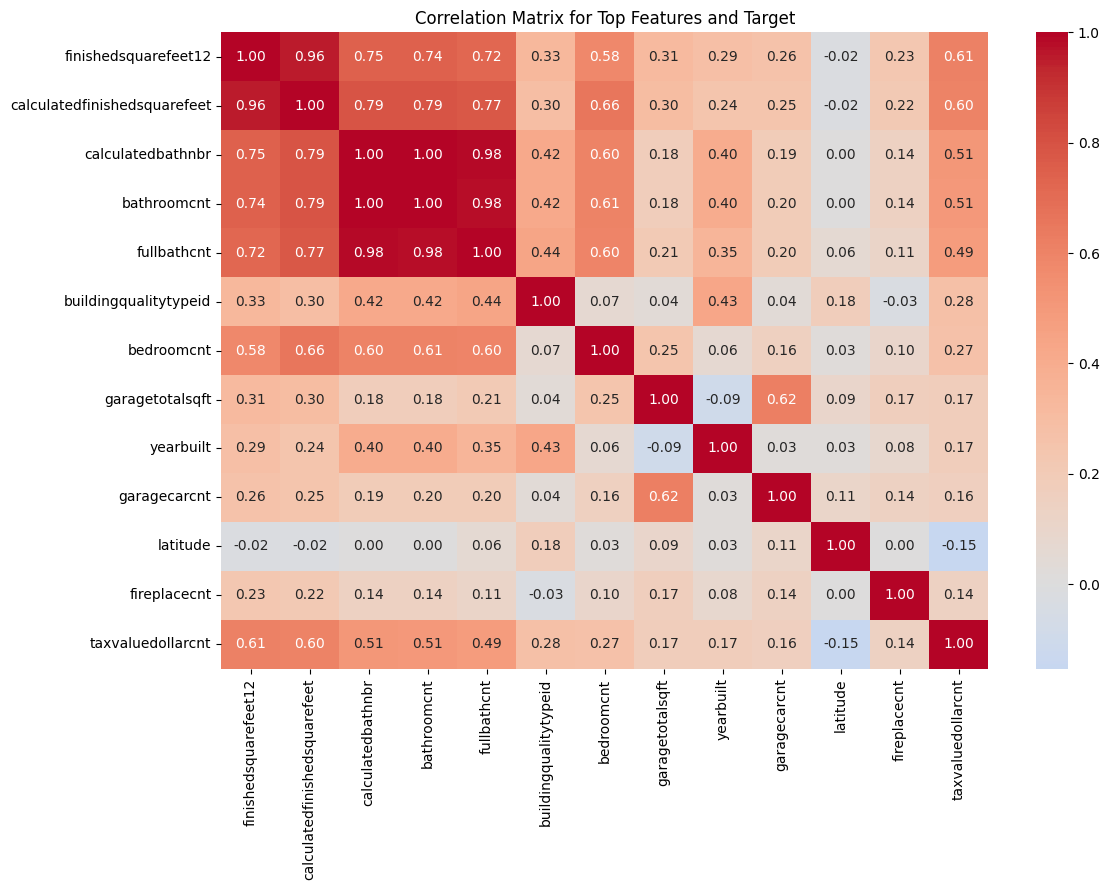

Top absolute correlations with taxvaluedollarcnt:
finishedsquarefeet12            0.612
calculatedfinishedsquarefeet    0.603
calculatedbathnbr               0.509
bathroomcnt                     0.508
fullbathcnt                     0.489
buildingqualitytypeid           0.278
bedroomcnt                      0.274
garagetotalsqft                 0.173
yearbuilt                       0.172
garagecarcnt                    0.161
latitude                        0.153
fireplacecnt                    0.142


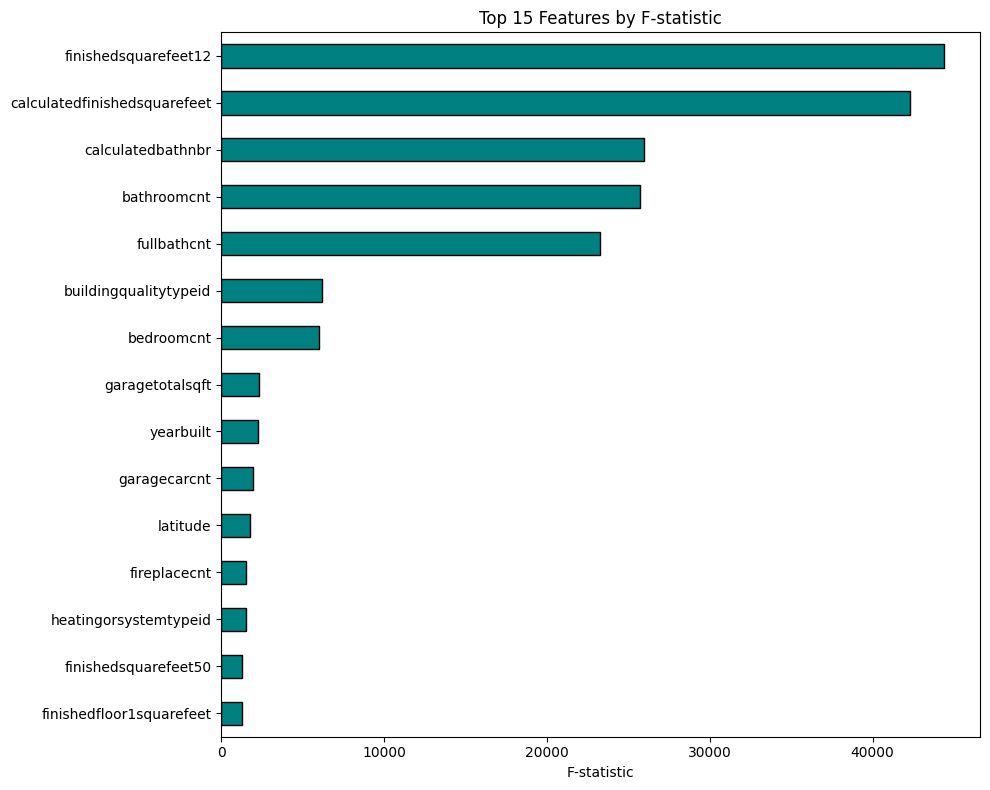


Top 15 features by F-statistic:
finishedsquarefeet12            44370.59
calculatedfinishedsquarefeet    42307.91
calculatedbathnbr               25956.29
bathroomcnt                     25721.08
fullbathcnt                     23273.81
buildingqualitytypeid            6205.57
bedroomcnt                       6018.90
garagetotalsqft                  2297.20
yearbuilt                        2257.90
garagecarcnt                     1979.69
latitude                         1782.00
fireplacecnt                     1513.80
heatingorsystemtypeid            1494.57
finishedsquarefeet50             1254.54
finishedfloor1squarefeet         1252.29

Sequential feature selection candidates:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'calculatedbathnbr', 'bathroomcnt', 'fullbathcnt', 'buildingqualitytypeid', 'bedroomcnt', 'garagetotalsqft', 'yearbuilt', 'garagecarcnt', 'latitude', 'fireplacecnt']

Forward-selected features:
['finishedsquarefeet12', 'calculatedfinishedsquarefeet', 'f

In [11]:
# Part 4.A: investigate feature relationships

from sklearn.linear_model import LinearRegression

analysis_df = X3e.copy()
target_col = "taxvaluedollarcnt"
X4 = analysis_df.drop(columns=[target_col])
y4 = analysis_df[target_col]

# 1) Correlation matrix focused on the features most correlated with the target
corr_with_target = analysis_df.corr(numeric_only=True)[target_col].drop(target_col)
corr_with_target_abs = corr_with_target.abs().sort_values(ascending=False)
top_corr_features = corr_with_target_abs.head(12).index.tolist()

corr_subset = analysis_df[top_corr_features + [target_col]].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_subset, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=False)
plt.title("Correlation Matrix for Top Features and Target")
plt.tight_layout()
plt.show()

print("Top absolute correlations with taxvaluedollarcnt:")
print(corr_with_target_abs.head(12).round(3).to_string())

# 2) F-statistics for all features
f_scores, p_values = f_regression(X4, y4)
fscore_series = pd.Series(f_scores, index=X4.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
fscore_series.head(15).sort_values().plot(kind="barh", color="teal", edgecolor="black")
plt.title("Top 15 Features by F-statistic")
plt.xlabel("F-statistic")
plt.tight_layout()
plt.show()

print("\nTop 15 features by F-statistic:")
print(fscore_series.head(15).round(2).to_string())

# 3) Forward and backward sequential feature selection
# Use the strongest F-score features as candidates to keep runtime practical.
sfs_candidate_features = fscore_series.head(12).index.tolist()
X4_sfs = X4[sfs_candidate_features]

sfs_sample_n = min(15000, len(X4_sfs))
X4_sfs_sample = X4_sfs.sample(n=sfs_sample_n, random_state=random_state)
y4_sfs_sample = y4.loc[X4_sfs_sample.index]

base_estimator = LinearRegression()
forward_sfs = SequentialFeatureSelector(
    base_estimator,
    n_features_to_select=6,
    direction="forward",
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)
backward_sfs = SequentialFeatureSelector(
    base_estimator,
    n_features_to_select=6,
    direction="backward",
    scoring="neg_root_mean_squared_error",
    cv=3,
    n_jobs=-1,
)

forward_sfs.fit(X4_sfs_sample, y4_sfs_sample)
backward_sfs.fit(X4_sfs_sample, y4_sfs_sample)

forward_selected = X4_sfs.columns[forward_sfs.get_support()].tolist()
backward_selected = X4_sfs.columns[backward_sfs.get_support()].tolist()

print("\nSequential feature selection candidates:")
print(sfs_candidate_features)
print("\nForward-selected features:")
print(forward_selected)
print("\nBackward-selected features:")
print(backward_selected)

#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?

The strongest relationships with `taxvaluedollarcnt` are clearly the size and bathroom-related variables: `finishedsquarefeet12` (0.612), `calculatedfinishedsquarefeet` (0.603), `calculatedbathnbr` (0.509), `bathroomcnt` (0.508), and `fullbathcnt` (0.489). The correlation matrix also shows strong redundancy among these predictors themselves, especially `calculatedbathnbr` with `bathroomcnt` (1.00) and with `fullbathcnt` (0.98), plus `finishedsquarefeet12` with `calculatedfinishedsquarefeet` (0.96), which suggests overlapping information. The F-statistics tell a very similar story: the same square-footage and bathroom variables dominate the rankings by a large margin, followed by building quality, bedroom count, and smaller garage/year-built effects. Forward and backward sequential selection broadly agree on a stable core set built around square footage, bedroom/bath structure, building quality, and location/year signals, but they differ slightly on which redundant bathroom and size variables to keep, which is exactly what we would expect when several predictors are highly correlated with each other.

### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

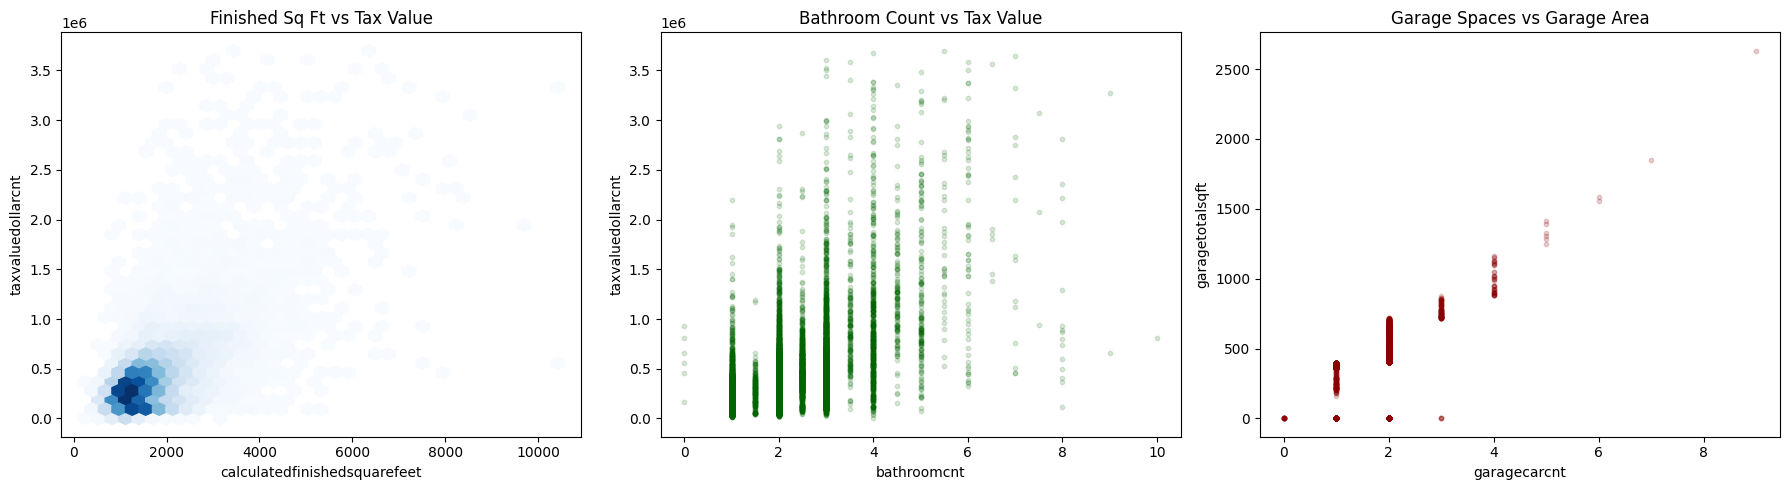

Selected pair correlations:
calculatedfinishedsquarefeet vs taxvaluedollarcnt: 0.603
bathroomcnt vs taxvaluedollarcnt: 0.508
garagecarcnt vs garagetotalsqft: 0.620


In [12]:
# Part 4.B: 2D visualizations for interesting feature pairs

plot_df = X3e.copy()
plot_sample = plot_df.sample(n=min(12000, len(plot_df)), random_state=random_state)

selected_pairs = [
    ("calculatedfinishedsquarefeet", "taxvaluedollarcnt"),
    ("bathroomcnt", "taxvaluedollarcnt"),
    ("garagecarcnt", "garagetotalsqft"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hexbin(
    plot_sample["calculatedfinishedsquarefeet"],
    plot_sample["taxvaluedollarcnt"],
    gridsize=35,
    cmap="Blues",
    mincnt=1,
)
axes[0].set_title("Finished Sq Ft vs Tax Value")
axes[0].set_xlabel("calculatedfinishedsquarefeet")
axes[0].set_ylabel("taxvaluedollarcnt")

axes[1].scatter(
    plot_sample["bathroomcnt"],
    plot_sample["taxvaluedollarcnt"],
    alpha=0.15,
    s=10,
    color="darkgreen",
)
axes[1].set_title("Bathroom Count vs Tax Value")
axes[1].set_xlabel("bathroomcnt")
axes[1].set_ylabel("taxvaluedollarcnt")

axes[2].scatter(
    plot_sample["garagecarcnt"],
    plot_sample["garagetotalsqft"],
    alpha=0.18,
    s=10,
    color="darkred",
)
axes[2].set_title("Garage Spaces vs Garage Area")
axes[2].set_xlabel("garagecarcnt")
axes[2].set_ylabel("garagetotalsqft")

plt.tight_layout()
plt.show()

print("Selected pair correlations:")
for left_col, right_col in selected_pairs:
    pair_corr = plot_df[[left_col, right_col]].corr().iloc[0, 1]
    print(f"{left_col} vs {right_col}: {pair_corr:.3f}")

#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.

`calculatedfinishedsquarefeet` versus `taxvaluedollarcnt` shows a clear positive relationship (correlation 0.603): larger homes tend to have higher assessed values, although the spread widens as square footage increases, so the relationship is not perfectly linear and high-value outliers remain. `bathroomcnt` versus `taxvaluedollarcnt` also shows a positive but step-like pattern (correlation 0.508), which makes sense because bathroom count is discrete; homes with more bathrooms generally trend upward in value, but there is still large variation within each bathroom level. `garagecarcnt` versus `garagetotalsqft` has a strong positive relationship (correlation 0.620), showing that garage area scales sensibly with vehicle capacity, with a few extreme large-garage outliers. Together, these plots reinforce that size/capacity features matter, while also showing heteroskedasticity, discreteness, and some outliers that may affect later model choice.

## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

,engineered_feature,base_feature,engineered_abs_corr,base_abs_corr,engineered_f_score
4,size_x_quality,calculatedfinishedsquarefeet,0.606,0.603,42906.657
0,log_finishedsquarefeet,calculatedfinishedsquarefeet,0.544,0.603,31189.646
3,bath_to_bed_ratio,bathroomcnt,0.229,0.508,4114.978
2,home_age,yearbuilt,0.172,0.172,2257.900
1,log_lotsizesquarefeet,lotsizesquarefeet,0.022,0.037,36.584


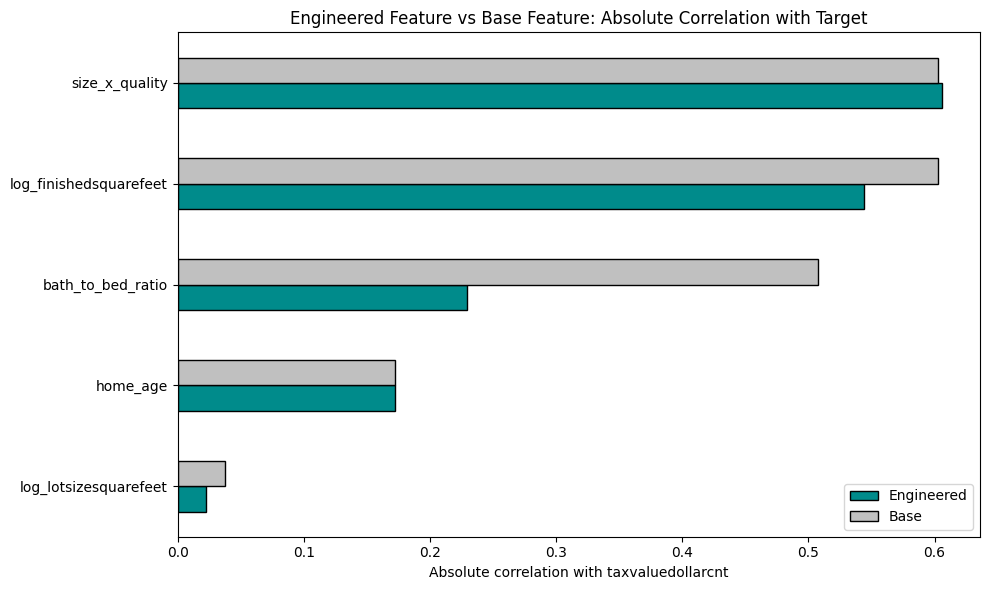

Engineered feature correlations with target:
log_finishedsquarefeet    0.544
log_lotsizesquarefeet     0.022
home_age                 -0.172
bath_to_bed_ratio         0.229
size_x_quality            0.606

Engineered feature F-scores:
size_x_quality            42906.66
log_finishedsquarefeet    31189.65
bath_to_bed_ratio          4114.98
home_age                   2257.90
log_lotsizesquarefeet        36.58

Top 10 SelectKBest features after adding engineered features:
['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'fullbathcnt', 'log_finishedsquarefeet', 'bath_to_bed_ratio', 'size_x_quality']

Engineered features that entered the top 10:
['log_finishedsquarefeet', 'bath_to_bed_ratio', 'size_x_quality']


In [10]:
# Part 5: investigate feature engineering transformations

feature_engineering_df = X3e.copy()
target_col_5 = "taxvaluedollarcnt"
y5 = feature_engineering_df[target_col_5]

# Candidate engineered features: log transforms, ratio, interaction, and age feature
feature_engineering_df["log_finishedsquarefeet"] = np.log1p(
    feature_engineering_df["calculatedfinishedsquarefeet"].clip(lower=0)
)
feature_engineering_df["log_lotsizesquarefeet"] = np.log1p(
    feature_engineering_df["lotsizesquarefeet"].clip(lower=0)
)
feature_engineering_df["home_age"] = 2016 - feature_engineering_df["yearbuilt"]
feature_engineering_df["bath_to_bed_ratio"] = np.where(
    feature_engineering_df["bedroomcnt"] > 0,
    feature_engineering_df["bathroomcnt"] / feature_engineering_df["bedroomcnt"],
    feature_engineering_df["bathroomcnt"],
)
feature_engineering_df["size_x_quality"] = (
    feature_engineering_df["calculatedfinishedsquarefeet"]
    * feature_engineering_df["buildingqualitytypeid"]
)

engineered_features = [
    "log_finishedsquarefeet",
    "log_lotsizesquarefeet",
    "home_age",
    "bath_to_bed_ratio",
    "size_x_quality",
]

base_feature_map = {
    "log_finishedsquarefeet": "calculatedfinishedsquarefeet",
    "log_lotsizesquarefeet": "lotsizesquarefeet",
    "home_age": "yearbuilt",
    "bath_to_bed_ratio": "bathroomcnt",
    "size_x_quality": "calculatedfinishedsquarefeet",
}

all_numeric_5 = feature_engineering_df.select_dtypes(include=[np.number])
corr_to_target_5 = all_numeric_5.corr()[target_col_5]

engineered_f_scores, _ = f_regression(feature_engineering_df[engineered_features], y5)
engineered_fscore_series = pd.Series(engineered_f_scores, index=engineered_features)

comparison_rows = []
for engineered_feature in engineered_features:
    base_feature = base_feature_map[engineered_feature]
    comparison_rows.append({
        "engineered_feature": engineered_feature,
        "base_feature": base_feature,
        "engineered_abs_corr": abs(corr_to_target_5[engineered_feature]),
        "base_abs_corr": abs(corr_to_target_5[base_feature]),
        "engineered_f_score": engineered_fscore_series[engineered_feature],
    })

feature_comparison = pd.DataFrame(comparison_rows).sort_values(
    "engineered_abs_corr", ascending=False
)

display(feature_comparison.round(3))

fig, ax = plt.subplots(figsize=(10, 6))
feature_comparison.sort_values("engineered_abs_corr").plot(
    x="engineered_feature",
    y=["engineered_abs_corr", "base_abs_corr"],
    kind="barh",
    edgecolor="black",
    color=["darkcyan", "silver"],
    ax=ax,
)
ax.set_title("Engineered Feature vs Base Feature: Absolute Correlation with Target")
ax.set_xlabel("Absolute correlation with taxvaluedollarcnt")
ax.set_ylabel("")
ax.legend(["Engineered", "Base"], loc="lower right")
plt.tight_layout()
plt.show()

# Check whether engineered features enter a top-k ranking alongside the existing features
X5_all = feature_engineering_df.drop(columns=[target_col_5])
selector_5 = SelectKBest(score_func=f_regression, k=10)
selector_5.fit(X5_all, y5)
selected_features_5 = X5_all.columns[selector_5.get_support()].tolist()
selected_scores_5 = pd.Series(selector_5.scores_, index=X5_all.columns).sort_values(ascending=False)

print("Engineered feature correlations with target:")
print(corr_to_target_5[engineered_features].round(3).to_string())

print("\nEngineered feature F-scores:")
print(engineered_fscore_series.sort_values(ascending=False).round(2).to_string())

print("\nTop 10 SelectKBest features after adding engineered features:")
print(selected_features_5)

engineered_selected_5 = [feature for feature in engineered_features if feature in selected_features_5]
print("\nEngineered features that entered the top 10:")
print(engineered_selected_5)

#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed. 

I chose a mix of common, interpretable transformations that match what we saw earlier in the data: log transforms for skewed size variables, an age feature derived from `yearbuilt`, a bathroom-to-bedroom ratio to capture layout balance, and an interaction term between home size and building quality. The most promising result was `size_x_quality`, which slightly improved on raw square footage and reached an absolute correlation of 0.606 with a very large F-score (42906.66), suggesting that size becomes more informative when combined with quality. `log_finishedsquarefeet` remained strong and entered the top 10 selected features, but it was still weaker than the unlogged original square-footage feature. `bath_to_bed_ratio` was not as strong as raw `bathroomcnt`, but it still carried useful signal and also entered the top 10. `home_age` was essentially equivalent to `yearbuilt` in absolute relationship strength, while `log_lotsizesquarefeet` added very little. Overall, these results suggest that interaction features may be more useful here than simple log transforms, and that some engineered variables are worth keeping available for model testing in Milestone 2 even if not all of them outperform the originals.

## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

